# DX 704 Week 3 Project

This week's project will give you practice with optimizing choices for bandit algorithms.
You will be given access to the bandit problem via a blackbox object, and you will investigate the bandit rewards to pick a suitable algorithm.

The full project description, a template notebook and supporting code are available on GitHub: [Project 3 Materials](https://github.com/bu-cds-dx704/dx704-project-03).


## Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Part 1: Pick a Bandit Algorithm

Experiment with the multi-armed bandit interface using seed 0 to learn about the distribution of rewards and decide what kind of bandit algorithm will be appropriate.
A histogram will likely be helpful.

In [4]:
# DO NOT CHANGE

import numpy as np

class BanditProblem(object):
    def __init__(self, seed):
        self.seed = seed
        self.rng = np.random.default_rng(seed)

        self.num_arms = 3
        self.ns = self.rng.integers(low=1, high=10, size=self.num_arms)
        self.ps = self.rng.uniform(low=0.2, high=0.4, size=self.num_arms)

    def get_num_arms(self):
        return self.num_arms

    def get_reward(self, arm):
        if arm < 0 or arm >= self.num_arms:
            raise ValueError("Invalid arm")

        x = self.rng.uniform()
        x *= self.rng.binomial(self.ns[arm], self.ps[arm])

        return x


In [5]:
bandit0 = BanditProblem(0)

In [6]:
bandit0.get_num_arms()

3

In [7]:
bandit0.get_reward(arm=0)

1.8255111545554434

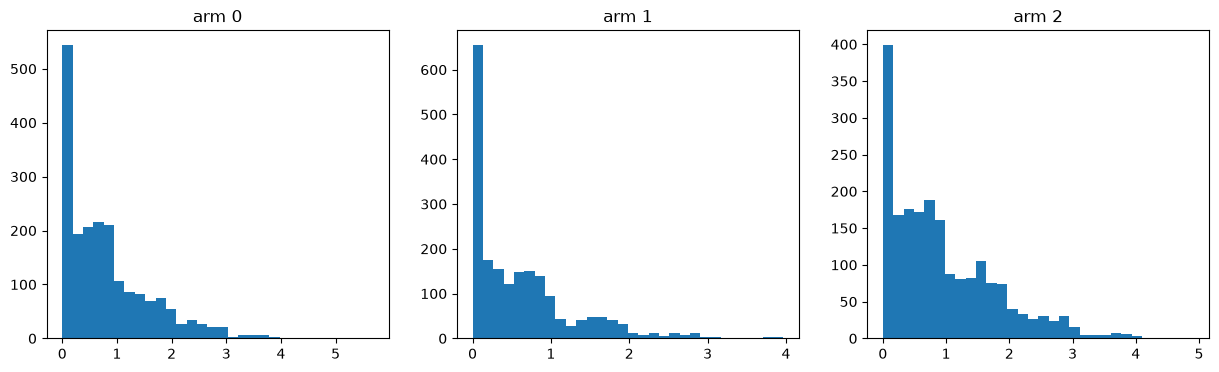

arm 0, min=0.0, max=5.685742425550971, mean=0.806277911652124
arm 1, min=0.0, max=3.9672742315445086, mean=0.5952545389872129
arm 2, min=0.0, max=4.91540639245513, mean=0.9287157631095102


In [11]:
# ================================================
# Visualize distribution of rewards for each arm
# ==============================================
import matplotlib.pyplot as plt

num_arms = bandit0.get_num_arms()
rewards = [[bandit0.get_reward(arm=arm) for _ in range(2000)] for arm in range(num_arms)]

fig, axes = plt.subplots(1, num_arms, figsize=(15, 4))
for arm, ax in enumerate(axes):
    ax.hist(rewards[arm], bins=30)
    ax.set_title(f"arm {arm}")
plt.show()

for arm in range(num_arms):
    print(f'arm {arm}, min={min(rewards[arm])}, max={max(rewards[arm])}, mean={sum(rewards[arm]) / len(rewards[arm])}')

Based on your investigation, pick an appropriate bandit algorithm to implement from the algorithms covered this week.
Write a file "algorithm-choice.txt" that states your choice and give a single sentence justifying your choice and rejecting the alternatives.
Keep your explanation concise; you should be able to justify your choice solely based on the type of numbers observed, and whether those match the bandit algorithms that you have learned.

## Part 2: Implement Bandit

Based on your decision, implement an appropriate bandit algorithm and pick 1000 actions using seed 2026.

In [12]:
# ============================
#  Epsilon-Greedy Algorithm
# ============================
import pandas as pd

def epsilon_greedy(bandit, epsilon, n_actions, rng):
    num_arms = bandit.get_num_arms()
    counts = [0] * num_arms
    values = [0.0] * num_arms
    history = []

    for step in range(n_actions):
        if step < num_arms:
            arm = step
        elif rng.random() < epsilon:
            arm = rng.integers(num_arms)
        else:
            arm = max(range(num_arms), key=lambda arm_index: values[arm_index])

        reward = bandit.get_reward(arm)
        counts[arm] += 1
        values[arm] += (reward - values[arm]) / counts[arm]
        history.append((arm, reward))

    return history


# =====================================
#  Implement Epsilon-Greedy Algorithm
# =====================================
implement_bandit = BanditProblem(2026)
rng = np.random.default_rng(2026)

history = epsilon_greedy(implement_bandit, epsilon=0.01, n_actions=1000, rng=rng)

Write a file "history.tsv" with columns action and reward in the order that the actions were taken.

In [13]:
# ==============================================
# Save results to TSV file named 'history.tsv'
# ==============================================
history_df = pd.DataFrame(
    history,
    columns=['action', 'reward']
    )

# Save file
history_df.to_csv('history.tsv', sep='\t', index=False)
history_df

,action,reward
0,0,3.162073
1,1,0.177353
2,2,0.298303
3,0,2.759550
4,0,1.505464
...,...,...
995,0,2.185100
996,0,0.354824
997,0,2.502218
998,0,0.982299


Submit "history.tsv" in Gradescope.

## Part 3: Action Statistics

Based on the data from part 2, estimate the expected reward for each arm and write a file "actions.tsv" with the columns action, min_reward, mean_reward, max_reward.

In [14]:
# ==========================================
# Estimate expected reward for each action
# ==========================================
min_expected_reward = history_df.groupby('action')['reward'].min()
print(min_expected_reward)

mean_expected_rewards = history_df.groupby('action')['reward'].mean()
print(mean_expected_rewards)

max_expected_reward = history_df.groupby('action')['reward'].max()
print(max_expected_reward)


# ==============================================
# Save results to TSV file named 'actions.tsv'
# ==============================================
actions_df = pd.DataFrame({
    'action': min_expected_reward.index,
    'min_reward': min_expected_reward.values,
    'mean_reward': mean_expected_rewards.values,
    'max_reward': max_expected_reward.values
    })

# Save file
actions_df.to_csv('actions.tsv', sep='\t', index=False)
actions_df

action
0    0.000000
1    0.000000
2    0.298303
Name: reward, dtype: float64
action
0    1.216927
1    0.111952
2    0.490896
Name: reward, dtype: float64
action
0    6.564312
1    0.382405
2    0.683490
Name: reward, dtype: float64


,action,min_reward,mean_reward,max_reward
0,0,0.000000,1.216927,6.564312
1,1,0.000000,0.111952,0.382405
2,2,0.298303,0.490896,0.683490


Submit "actions.tsv" in Gradescope.

## Part 4: Regret Estimates

Estimate the regret taking 1000 actions with the following strategies.

* uniform: Pick an arm uniformly at random.
* just-i: Always pick arm $i$. Do this for $i=0$ to $K-1$ where $K$ is the number of arms.
* actual: This should match your output in part 2.

These estimates should be based on your previous action statistics; you should not use the true action values from the bandit code.

In [15]:
# =================
# Estimate Regret
# =================
n_actions = len(history_df)
best_reward_estimate = mean_expected_rewards.max()

regrets = {}

# uniform: pick an arm uniformly at random
uniform_reward_estimate = mean_expected_rewards.mean()
regrets["uniform"] = n_actions * (best_reward_estimate - uniform_reward_estimate)
# print(f'uniform: {regrets["uniform"]}')

# just-i: always pick arm i
for arm in mean_expected_rewards.index:
    regrets[f"just-{arm}"] = n_actions * (best_reward_estimate - mean_expected_rewards[arm])
    # print(f'just-{arm}: {regrets[f"just-{arm}"]}')

# actual: matches the epsilon-greedy history from part 2
actual_total_reward = history_df["reward"].sum()
regrets["actual"] = n_actions * best_reward_estimate - actual_total_reward
# print(f'actual: {regrets["actual"]}')

regrets

{'uniform': np.float64(610.3350787461139),
 'just-0': np.float64(0.0),
 'just-1': np.float64(1104.9749256255172),
 'just-2': np.float64(726.0303106128246),
 'actual': np.float64(6.976935249353119)}

Write your results to a file "strategies.tsv" with the columns strategy and regret.

In [16]:
# ==============================================
# Save results to TSV file named 'strategies.tsv'
# ==============================================
strategies_df = pd.DataFrame({
    "strategy": list(regrets.keys()),
    "regret": list(regrets.values())
    })

# Save file
strategies_df.to_csv('strategies.tsv', sep='\t', index=False)
strategies_df

,strategy,regret
0,uniform,610.335079
1,just-0,0.000000
2,just-1,1104.974926
3,just-2,726.030311
4,actual,6.976935


Submit "strategies.tsv" in Gradescope.

## Part 5: Acknowledgments

Make a file "acknowledgments.txt" documenting any outside sources or help on this project.
If you discussed this assignment with anyone, please acknowledge them here.
If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for.
If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy.
If no acknowledgements are appropriate, just write none in the file.


Submit "acknowledgments.txt" in Gradescope.

## Part 6: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.

Submit "project.ipynb" in Gradescope.